# Criação de composição temporal para cubos de dados

Pipeline:
1. Acessar imagens e bandas pelo STAC e salvar imagens originais
    - 1.1 Ver imagens originais
2. Remover nuvens e salvar imagens sem nuvens
    - 2.1 Ver imagens sem nuvens
3. Declarar os métodos de composição temporal
4. Escolher o método
5. Rodar o método
6. Ver resultado pós-método

## 1. Acessar imagem e bandas pelo STAC e salvar imagens originais

In [1]:
import os
import glob
import math
import warnings
import numpy as np
import xarray as xr
import rasterio
import rasterio.windows
from rasterio.plot import show
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine
import matplotlib.pyplot as plt
from tqdm import tqdm
import pystac_client
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Configuração STAC
servico = "https://data.inpe.br/bdc/stac/v1/"
catalogo = pystac_client.Client.open(servico)

colecao = ["S2_L2A-1"]
periodo_composicao = "2024-08-18/2024-08-25"
bandas_espectrais = ["B12", "B08", "B04"] 
banda_qa = "SCL"
todas_bandas = bandas_espectrais + [banda_qa]
bbox = [-49.87930174, -20.37185787, -49.53239264, -20.03585787]
filtros = {"eo:cloud_cover": {"lt": 70}}

item_search = catalogo.search(
    bbox=bbox,
    collections=colecao,
    query=filtros,
    datetime=periodo_composicao,
)

items = sorted(list(item_search.item_collection()), key=lambda x: x.datetime)
print(f"Total de {len(items)} cenas encontradas no período.")

urls_por_banda = {banda: [item.assets[banda].href for item in items] for banda in todas_bandas}
print(f"URLs extraídas com sucesso para as bandas: {', '.join(urls_por_banda.keys())}")

Total de 3 cenas encontradas no período.
URLs extraídas com sucesso para as bandas: B12, B08, B04, SCL


In [2]:
# Função de pré-processamento (máscara de nuvens via banda SCL)
def apply_cloud_mask_scl(data_array, scl_array, valid_classes=[4, 5, 6]):
    """
    Remove nuvens e sombras utilizando a banda SCL do Sentinel-2.
    Classes padrão: 4 (Vegetação), 5 (Solo Exposto), 6 (Água).
    Pixels fora dessas classes recebem np.nan.
    """
    mask = ~np.isin(scl_array, valid_classes)
    clean_data = data_array.astype(np.float32).copy()
    clean_data[mask] = np.nan
    return clean_data


# Função de reamostragem espacial 10m -> 20m
def transforme_20m_array(arr_10m, transform_10m, crs):
    '''
    Reamostragem de um bloco (array numpy) de 10m para 20m.
    Baseado na função original.
    '''
    # Cria a nova transformação Affine para 20m baseada na janela de 10m
    tranform_20m = Affine(20.0, 0.0, transform_10m.c,
                          transform_10m.d, -20.0, transform_10m.f)
    # Cria uma matriz numpy para o resultado reamostrado (metade das dimensões)
    out_shape = (int(arr_10m.shape[0] / 2), int(arr_10m.shape[1] / 2))
    array_20m = np.zeros(out_shape, dtype=arr_10m.dtype)
    reproject(
        source=arr_10m,
        destination=array_20m,
        src_transform=transform_10m,
        src_crs=crs,
        dst_transform=tranform_20m,
        dst_crs=crs,
        src_nodata=0, 
        dst_nodata=0, 
        resampling=Resampling.nearest
    )
    return array_20m

In [3]:
def save_original_images(urls_dict, todas_bandas, items, out_dir):
    """
    Lê dados via STAC e salva imagens originais multibanda localmente.
    A primeira banda de `todas_bandas` define a grade de referência
    (resolução e janelas). Bandas em resolução mais alta (ex.: B04, B08
    a 10m) são reamostradas via `transforme_20m_array` antes de gravar.
    """
    os.makedirs(out_dir, exist_ok=True)
    primeira_banda = todas_bandas[0]

    env_kwargs = {
        'GDAL_DISABLE_READDIR_ON_OPEN': 'EMPTY_DIR',
        'CPL_VSIL_CURL_ALLOWED_EXTENSIONS': 'tif',
        'VSI_CACHE': 'TRUE'
    }

    for i in tqdm(range(len(items)), desc="Salvando imagens originais"):
        date_str = items[i].datetime.strftime("%Y%m%d")
        # Naming pattern: S2_orig_<data>_<idx>.tif (data no índice [2] de split('_'))
        out_path = os.path.join(out_dir, f"S2_orig_{date_str}_{i}.tif")

        if os.path.exists(out_path):
            continue

        with rasterio.Env(**env_kwargs):
            # Banda de referência define a grade de saída (resolução + janelas)
            with rasterio.open(urls_dict[primeira_banda][i]) as src:
                meta = src.meta.copy()
                windows = list(src.block_windows())
                ref_res = src.transform.a  # tamanho do pixel de referência

            meta.update(count=len(todas_bandas))

            with rasterio.open(out_path, "w", **meta) as dst:
                for band_index, banda in enumerate(todas_bandas, start=1):
                    with rasterio.open(urls_dict[banda][i]) as src_b:
                        band_res = src_b.transform.a
                        precisa_reamostrar = band_res < ref_res  # ex.: 10m < 20m

                        for _, window in windows:
                            if precisa_reamostrar:
                                # Janela equivalente no espaço da banda em alta resolução
                                escala = ref_res / band_res
                                window_hires = rasterio.windows.Window(
                                    col_off=int(window.col_off * escala),
                                    row_off=int(window.row_off * escala),
                                    width=int(window.width * escala),
                                    height=int(window.height * escala),
                                )
                                arr_hires = src_b.read(1, window=window_hires)
                                transform_hires = rasterio.windows.transform(
                                    window_hires, src_b.transform
                                )
                                # Aplica a reamostragem 10m -> 20m
                                arr_out = transforme_20m_array(
                                    arr_hires, transform_hires, src_b.crs
                                )
                            else:
                                arr_out = src_b.read(1, window=window)
                            dst.write(arr_out, band_index, window=window)
                    dst.set_band_description(band_index, banda)

    print(f"✓ Imagens originais salvas em {out_dir}")

# Executando: salva as imagens originais localmente
os.makedirs('./output', exist_ok=True)
DIR_ORIGINAIS = './output/originais'

save_original_images(urls_por_banda, todas_bandas, items, DIR_ORIGINAIS)

Salvando imagens originais: 100%|██████████| 3/3 [00:00<00:00, 8144.28it/s]

✓ Imagens originais salvas em ./output/originais


### 1.1 Ver imagens originais

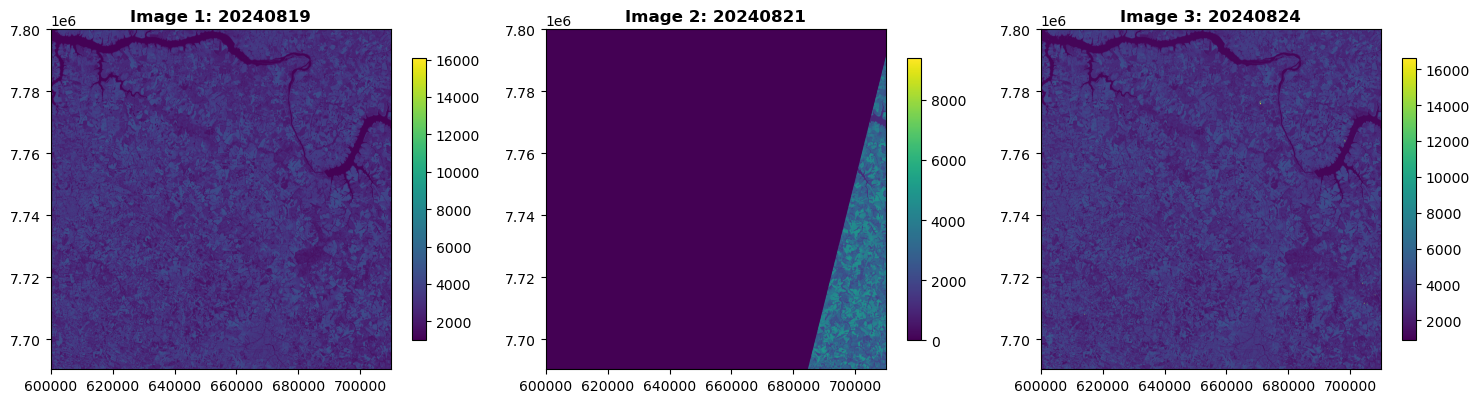

In [ ]:
def plot_source_images(input_dir, max_images=12):
    # Get list of TIFFs
    tif_files = sorted(glob.glob(os.path.join(input_dir, "*.tif")))[:max_images]
    num_files = len(tif_files)

    if num_files == 0:
        print("No images found.")
        return

    # Calculate grid dimensions (rows/cols)
    cols = 3 if num_files > 3 else num_files
    rows = math.ceil(num_files / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    
    if num_files > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    for i, file_path in enumerate(tif_files):
        with rasterio.open(file_path) as src:
            title = os.path.basename(file_path).split('_')[2] 
            
            img = show(src, ax=axes_flat[i], title=f"Image {i+1}: {title}", cmap='viridis')
            
            im = axes_flat[i].get_images()[0]
            fig.colorbar(im, ax=axes_flat[i], shrink=0.6)

    # Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

# Plotando as imagens originais
plot_source_images(DIR_ORIGINAIS)

## 2. Remover nuvens e salvar imagens sem nuvens

In [5]:
def remove_clouds_and_save(input_dir, output_dir, bandas_espectrais, banda_qa="SCL"):
    """
    Lê as imagens originais salvas, aplica a máscara de nuvens (SCL) e
    salva imagens limpas (apenas com as bandas espectrais, em float32 com NaN).
    Usa apply_cloud_mask_scl declarada na célula de declarações.
    """
    os.makedirs(output_dir, exist_ok=True)
    tif_files = sorted(glob.glob(os.path.join(input_dir, "*.tif")))

    if not tif_files:
        raise FileNotFoundError(f"Nenhum .tif encontrado em: {input_dir}")

    n_bandas_esp = len(bandas_espectrais)

    for f in tqdm(tif_files, desc="Removendo nuvens"):
        out_name = os.path.basename(f).replace("_orig_", "_clean_")
        out_path = os.path.join(output_dir, out_name)

        with rasterio.open(f) as src:
            descriptions = list(src.descriptions)
            scl_idx = descriptions.index(banda_qa) + 1
            scl_array = src.read(scl_idx)

            meta = src.meta.copy()
            meta.update(count=n_bandas_esp, dtype=rasterio.float32, nodata=np.nan)

            with rasterio.open(out_path, "w", **meta) as dst:
                for band_index, banda in enumerate(bandas_espectrais, start=1):
                    src_idx = descriptions.index(banda) + 1
                    arr = src.read(src_idx)
                    clean = apply_cloud_mask_scl(arr, scl_array)
                    dst.write(clean, band_index)
                    dst.set_band_description(band_index, banda)

    print(f"✓ Imagens sem nuvens salvas em {output_dir}")

# Executando: aplica máscara de nuvens nas imagens originais
DIR_LIMPAS = './output/sem_nuvens'
remove_clouds_and_save(DIR_ORIGINAIS, DIR_LIMPAS, bandas_espectrais, banda_qa="SCL")

Removendo nuvens: 100%|██████████| 3/3 [00:03<00:00,  1.30s/it]

✓ Imagens sem nuvens salvas em ./output/sem_nuvens


### 2.1 Ver imagens sem nuvens

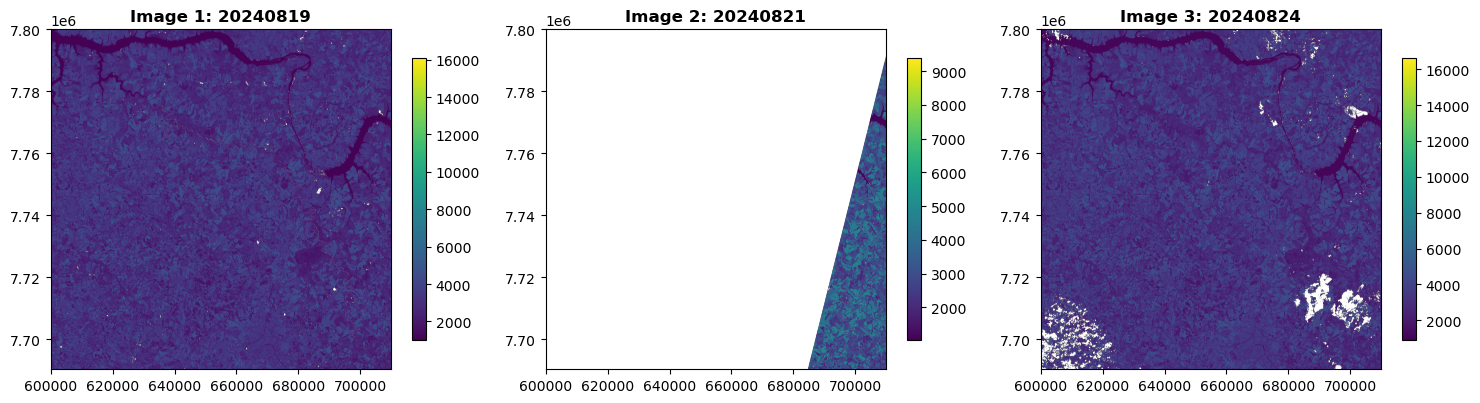

In [6]:
# Plotando as imagens já com nuvens removidas
plot_source_images(DIR_LIMPAS)

## 3. Declarar os métodos de composição temporal

Métodos disponíveis (agora baseados nas **novas funções xarray** do
notebook *ProgGeo_Novas_Funcoes*):

- `"avg"`  → `gerar_composicao_media`     (média, ignora NaN)
- `"med"`  → `gerar_composicao_mediana`   (mediana, ignora NaN)
- `"minx"` → `gerar_composicao_min` (k=1) ou `gerar_composicao_extrema(tipo='min')` (k>1) — **com proveniência**
- `"maxx"` → `gerar_composicao_max` (k=1) ou `gerar_composicao_extrema(tipo='max')` (k>1) — **com proveniência**

> Mudança semântica para `minx`/`maxx`: o índice temporal é decidido
> pela banda de referência (`BANDA_REF`, padrão `"B12"`) e o **mesmo
> índice por pixel** é aplicado a todas as bandas — diferente da versão
> antiga, que escolhia o k-ésimo extremo banda-a-banda. Isso mantém
> consistência espectral no pixel composto.

In [ ]:
def gerar_composicao_media(cubo_limpo):
    """
    Retorna a composição baseada na média temporal.
    Não possui proveniência (a média mistura as datas).
    """
    return cubo_limpo.mean(dim='time')


def gerar_composicao_mediana(cubo_limpo):
    """
    Retorna a composição baseada na mediana temporal.
    Não possui proveniência (a mediana mistura as datas).
    """
    return cubo_limpo.median(dim='time')


def gerar_composicao_max(cubo_limpo, banda_reff='B12'):
    """
    Retorna a composição temporal baseada no máximo da banda de referência
    e a respectiva proveniência (data escolhida pixel-a-pixel).
    """
    banda_temp = cubo_limpo[banda_reff].fillna(-np.inf)
    indice_max = banda_temp.argmax(dim='time', skipna=True).compute()

    compo_max = cubo_limpo.isel(time=indice_max)
    compo_provenence = cubo_limpo['time'].isel(time=indice_max)
    return compo_max, compo_provenence


def gerar_composicao_min(cubo_limpo, banda_reff='B12'):
    """
    Retorna a composição temporal baseada no mínimo da banda de referência
    e a respectiva proveniência.
    """
    banda_temp = cubo_limpo[banda_reff].fillna(np.inf)
    indice_min = banda_temp.argmin(dim='time', skipna=True).compute()

    compo_min = cubo_limpo.isel(time=indice_min)
    compo_provenence = cubo_limpo['time'].isel(time=indice_min)
    return compo_min, compo_provenence


def achar_indice_do_enesimo(matriz_3d, enesimo, tipo='max'):
    """
    matriz_3d tem o formato (Y, X, Tempo) — o tempo vai para o último
    eixo no apply_ufunc. Retorna o índice temporal do k-ésimo extremo
    por pixel, ignorando NaN.
    """
    quantidade_tempo = matriz_3d.shape[-1] 

    if quantidade_tempo < 1:
        raise ValueError(
            "Erro: A matriz temporal está vazia (0 datas). "
            "Não é possível buscar máximos ou mínimos."
        )

    # Não pede um índice maior do que a quantidade de imagens
    n_seguro = min(enesimo, quantidade_tempo)

    if tipo == 'max':
        matriz_segura = np.where(np.isnan(matriz_3d), -np.inf, matriz_3d)
        indices_ordenados = np.argsort(matriz_segura, axis=-1)
        return indices_ordenados[:, :, -n_seguro]

    elif tipo == 'min':
        matriz_segura = np.where(np.isnan(matriz_3d), np.inf, matriz_3d)
        indices_ordenados = np.argsort(matriz_segura, axis=-1)
        return indices_ordenados[:, :, n_seguro - 1]

    else:
        raise ValueError("O parâmetro 'tipo' deve ser 'max' ou 'min'.")


def gerar_composicao_extrema(cubo_limpo, banda_ref='B12', enesimo=1, tipo='max'):
    """
    Retorna a composição e a proveniência baseadas no k-ésimo máximo ou
    mínimo da banda de referência.
    """
    print(f"Calculando composição: {enesimo}º {tipo.upper()} usando {banda_ref} como referência...")

    cubo_proc = cubo_limpo.chunk({'time': -1})

    indice_virtual = xr.apply_ufunc(
        achar_indice_do_enesimo,
        cubo_proc[banda_ref],
        kwargs={'enesimo': enesimo, 'tipo': tipo},
        input_core_dims=[['time']],
        output_core_dims=[[]],
        dask='parallelized',
        output_dtypes=[int]
    )

    # Materializa o índice
    indice_real = indice_virtual.compute()

    # Recorta o cubo no tempo certo por pixel
    compo_final = cubo_limpo.isel(time=indice_real)
    proveniencia = cubo_limpo['time'].isel(time=indice_real)

    # Limpeza de coord 'time' não-dimensional residual
    if 'time' in compo_final.coords:
        compo_final = compo_final.drop_vars('time')

    return compo_final, proveniencia


## 4. Escolher o método

Defina abaixo qual método de composição temporal será aplicado.
Para `"minx"` ou `"maxx"`, ajuste também o valor de `k`.

In [8]:
# Escolha aqui o método: "avg", "med", "minx" ou "maxx"
MOSAIC_METHOD = "minx"
K = 1                # usado apenas para "minx" e "maxx"
BANDA_REF = "B12"    # banda de referência (apenas "minx"/"maxx")

print(f"Método escolhido: {MOSAIC_METHOD} (k={K}, banda_ref={BANDA_REF})")


Método escolhido: minx (k=1, banda_ref=B12)


## 5. Rodar o método

In [ ]:
def _ler_cubo_janela(tif_files, bandas_espectrais, window):
    """
    Lê uma janela de todos os tifs de entrada e devolve um xarray.Dataset
    com dims (time, y, x), uma data_var por banda. As datas são extraídas
    do nome (S2_clean_<YYYYMMDD>_<idx>.tif).
    """
    # Datas a partir do nome dos arquivos
    datas = []
    for f in tif_files:
        date_str = os.path.basename(f).split("_")[2]  # YYYYMMDD
        datas.append(np.datetime64(
            f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}"
        ))
    datas = np.array(datas, dtype="datetime64[ns]")

    # (time, y, x) por banda
    data_vars = {}
    for band_index, banda in enumerate(bandas_espectrais, start=1):
        stack = []
        for f in tif_files:
            with rasterio.open(f) as src:
                stack.append(src.read(band_index, window=window))
        stack = np.array(stack, dtype=np.float32)
        data_vars[banda] = (("time", "y", "x"), stack)

    return xr.Dataset(data_vars, coords={"time": datas})


def _aplicar_metodo(cubo_window, mosaic_method, k, banda_ref):
    """
    Despachante: chama a função nova adequada e devolve sempre uma tupla
    (composicao_xr.Dataset_2D, proveniencia_xr.DataArray_2D_ou_None).
    """
    if mosaic_method == "avg":
        return gerar_composicao_media(cubo_window), None

    if mosaic_method == "med":
        return gerar_composicao_mediana(cubo_window), None

    if mosaic_method == "minx":
        if k == 1:
            return gerar_composicao_min(cubo_window, banda_reff=banda_ref)
        return gerar_composicao_extrema(
            cubo_window, banda_ref=banda_ref, enesimo=k, tipo="min"
        )

    if mosaic_method == "maxx":
        if k == 1:
            return gerar_composicao_max(cubo_window, banda_reff=banda_ref)
        return gerar_composicao_extrema(
            cubo_window, banda_ref=banda_ref, enesimo=k, tipo="max"
        )

    raise ValueError(f"Método {mosaic_method} não reconhecido.")


def _proveniencia_para_int(prov_da):
    """datetime64 -> int32 AAAAMMDD (mesma convenção do novo notebook)."""
    return (
        prov_da.dt.year.values * 10000
        + prov_da.dt.month.values * 100
        + prov_da.dt.day.values
    ).astype("int32")


def run_temporal_composition(input_dir, out_path, bandas_espectrais,
                             mosaic_method="avg", k=1, banda_ref="B12",
                             out_path_prov=None):
    """
    Lê imagens limpas (sem nuvens) e aplica a composição temporal pixel-a-pixel
    usando as NOVAS funções (xarray). Processa por blocos para economizar
    memória. Gera um TIF multibanda com a composição e, para min/max, um
    segundo TIF de proveniência (datas como inteiros AAAAMMDD).
    """
    tif_files = sorted(glob.glob(os.path.join(input_dir, "*.tif")))
    if not tif_files:
        raise FileNotFoundError(f"Nenhum .tif encontrado em: {input_dir}")

    with rasterio.open(tif_files[0]) as src:
        meta = src.meta.copy()
        windows = list(src.block_windows())

    # Composição: float32 com NaN
    meta_compo = meta.copy()
    meta_compo.update(count=len(bandas_espectrais),
                      dtype=rasterio.float32, nodata=np.nan)

    # Proveniência: int32 com 0 = sem dado (apenas se min/max)
    needs_prov = mosaic_method in ("minx", "maxx")
    if needs_prov and out_path_prov is None:
        base, ext = os.path.splitext(out_path)
        out_path_prov = f"{base}_proveniencia{ext}"

    meta_prov = meta.copy()
    meta_prov.update(count=1, dtype=rasterio.int32, nodata=0)

    dst_prov = rasterio.open(out_path_prov, "w", **meta_prov) if needs_prov else None

    try:
        with rasterio.open(out_path, "w", **meta_compo) as dst:
            for _, window in tqdm(windows, desc=f"Compondo ({mosaic_method})"):
                # 1. Constrói o cubo (xarray) da janela
                cubo_window = _ler_cubo_janela(tif_files, bandas_espectrais, window)

                # 2. Aplica a função nova
                compo, prov = _aplicar_metodo(cubo_window, mosaic_method, k, banda_ref)

                # 3. Garante 2D por banda (sem coord 'time' residual)
                if "time" in compo.coords:
                    compo = compo.drop_vars("time")

                # 4. Escreve cada banda da composição
                for band_index, banda in enumerate(bandas_espectrais, start=1):
                    arr = compo[banda].values.astype(np.float32)
                    dst.write(arr, band_index, window=window)

                # 5. Escreve a proveniência (só min/max)
                if needs_prov and prov is not None:
                    dst_prov.write(_proveniencia_para_int(prov), 1, window=window)

            for band_index, banda in enumerate(bandas_espectrais, start=1):
                dst.set_band_description(band_index, banda)
    finally:
        if dst_prov is not None:
            dst_prov.close()

    print(f"✓ Composição salva em: {out_path}")
    if needs_prov:
        print(f"✓ Proveniência salva em: {out_path_prov}")


# Executando: aplica o método escolhido sobre as imagens sem nuvens
OUT_COMPOSITE = f"./output/composite_{MOSAIC_METHOD}.tif"

run_temporal_composition(
    input_dir=DIR_LIMPAS,
    out_path=OUT_COMPOSITE,
    bandas_espectrais=bandas_espectrais,
    mosaic_method=MOSAIC_METHOD,
    k=K,
    banda_ref=BANDA_REF,
)


Compondo (minx): 100%|██████████| 5490/5490 [01:33<00:00, 58.65it/s]

✓ Composição salva em: ./output/composite_minx.tif
✓ Proveniência salva em: ./output/composite_minx_proveniencia.tif


## 6. Ver resultado pós-método

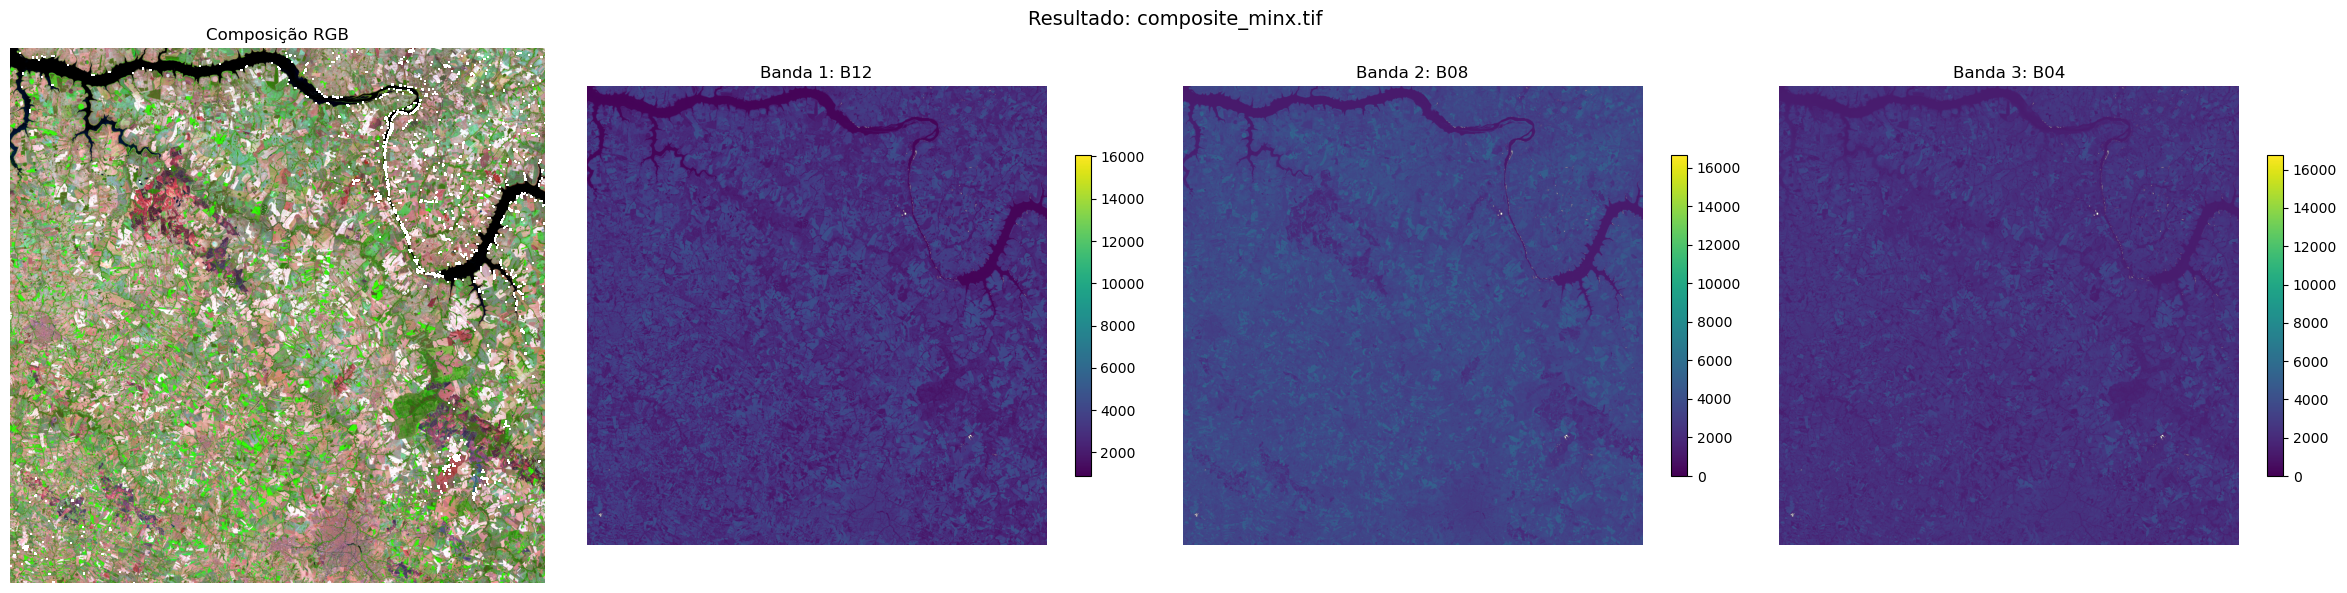

In [10]:
def plot_composite(composite_path):
    """
    Plota o composite final. Se houver 3+ bandas, exibe uma composição RGB
    (com normalização por percentil); caso contrário, exibe a banda única.
    """
    with rasterio.open(composite_path) as src:
        n_bands = src.count
        descriptions = src.descriptions

        if n_bands >= 3:
            fig, axes = plt.subplots(1, n_bands + 1, figsize=(6 * (n_bands + 1), 6))

            # Composição RGB (assume ordem das bandas espectrais como R,G,B)
            data = src.read([1, 2, 3]).astype(np.float32)
            rgb = np.zeros_like(data)
            for i in range(3):
                p2, p98 = np.nanpercentile(data[i], [2, 98])
                rgb[i] = np.clip((data[i] - p2) / (p98 - p2 + 1e-9), 0, 1)
            axes[0].imshow(np.transpose(rgb, (1, 2, 0)))
            axes[0].set_title("Composição RGB")
            axes[0].axis('off')

            # Cada banda separadamente
            for i in range(n_bands):
                arr = src.read(i + 1)
                im = axes[i + 1].imshow(arr, cmap='viridis')
                axes[i + 1].set_title(f"Banda {i+1}: {descriptions[i] or ''}")
                axes[i + 1].axis('off')
                fig.colorbar(im, ax=axes[i + 1], shrink=0.6)
        else:
            fig, ax = plt.subplots(1, 1, figsize=(10, 10))
            show(src, ax=ax, cmap='viridis', title=os.path.basename(composite_path))
            im = ax.get_images()[0]
            fig.colorbar(im, ax=ax, shrink=0.6)

        plt.suptitle(f"Resultado: {os.path.basename(composite_path)}", fontsize=14)
        plt.tight_layout()
        plt.show()

# Plotando o resultado final
plot_composite(OUT_COMPOSITE)